Para estos ejercicios, necesitamos una función ligeramente diferente a la anterior, ya que aquí los límites no tienden al infinito, sino a **puntos específicos** (asíntotas verticales). La aproximación tabular debe hacerse con valores muy cercanos al punto crítico por izquierda y derecha.

Aquí tienes la función de Python diseñada para estos casos:



--- Análisis para x -> 1  ---
Valor del límite (SymPy): oo

Aproximación Tabular:
     x         f(x)
0.9999 1.999600e+08
0.9990 1.996001e+06
0.9900 1.960100e+04
0.9000 1.610000e+02
1.1000 2.410000e+02
1.0100 2.040100e+04
1.0010 2.004001e+06
1.0001 2.000400e+08
----------------------------------------


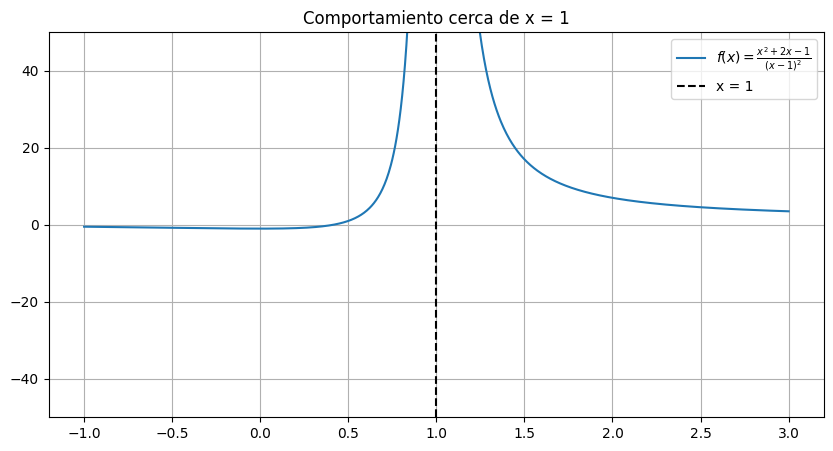

In [3]:
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
import plotly.graph_objects as go

def analizar_limite_punto(f_expr, punto, lateral=None):
    """
    Analiza límites en un punto específico (asíntotas).
    
    Args:
        f_expr: Expresión de SymPy.
        punto: El valor de x al que tiende el límite.
        lateral: None (bilateral), "+" (derecha) o "-" (izquierda).
    """
    x = sp.Symbol('x')
    
    # --- CORRECCIÓN AQUÍ ---
    # SymPy usa '+-' para límites bilaterales, no 'bidirectional'
    dir_symbol = '+-' if lateral is None else lateral
    
    # 1. Cálculo Simbólico con SymPy
    limite_valor = sp.limit(f_expr, x, punto, dir=dir_symbol)
    
    print(f"--- Análisis para x -> {punto} {'(por ' + lateral + ')' if lateral else ''} ---")
    print(f"Valor del límite (SymPy): {limite_valor}\n")

    # 2. Análisis Tabular con Pandas
    delta = [0.1, 0.01, 0.001, 0.0001]
    
    if lateral == "-":
        valores_x = [punto - d for d in delta]
    elif lateral == "+":
        valores_x = [punto + d for d in delta]
    else: # Bilateral (mostramos ambos lados en la tabla)
        izq = [punto - d for d in reversed(delta)]
        der = [punto + d for d in delta]
        valores_x = izq + der
    
    f_num = sp.lambdify(x, f_expr, 'numpy')
    
    # Manejo de errores para división por cero
    resultados_y = []
    for val in valores_x:
        try:
            res = float(f_num(val))
        except (ZeroDivisionError, RuntimeWarning):
            res = np.nan
        resultados_y.append(res)

    df = pd.DataFrame({'x': valores_x, 'f(x)': resultados_y})
    print("Aproximación Tabular:")
    print(df.to_string(index=False))
    print("-" * 40)

    # 3. Visualización Gráfica (Matplotlib)
    rango = 2
    x_plot = np.linspace(punto - rango, punto + rango, 1000)
    # Filtramos valores extremadamente altos para que el gráfico sea legible
    y_plot = f_num(x_plot)
    y_plot[np.abs(y_plot) > 100] = np.nan 

    plt.figure(figsize=(10, 5))
    plt.plot(x_plot, y_plot, label=f'$f(x) = {sp.latex(f_expr)}$')
    plt.axvline(x=punto, color='k', linestyle='--', label=f'x = {punto}')
    plt.title(f"Comportamiento cerca de x = {punto}")
    plt.ylim(-50, 50) 
    plt.grid(True)
    plt.legend()
    plt.savefig(f"limite_{punto}_{lateral if lateral else 'bilateral'}.png")
    plt.show()

    # 4. Visualización Interactiva (Plotly)
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=x_plot, y=y_plot, name='f(x)'))
    fig.add_vline(x=punto, line_dash="dash", line_color="black")
    fig.update_layout(title=f"Gráfico Interactivo cerca de x = {punto}", yaxis_range=[-50, 50])
    fig.write_image(f"limite_{punto}_{lateral if lateral else 'bilateral'}_interactive.png")
    fig.show()

# --- PRUEBA CON EL EJERCICIO (a) ---
x = sp.Symbol('x')
f_a = (x**2 + 2*x - 1) / (x - 1)**2
analizar_limite_punto(f_a, 1)

EJERCICIO (a)
--- Análisis para x -> 1  ---
Valor del límite (SymPy): oo

Aproximación Tabular:
     x         f(x)
0.9999 1.999600e+08
0.9990 1.996001e+06
0.9900 1.960100e+04
0.9000 1.610000e+02
1.1000 2.410000e+02
1.0100 2.040100e+04
1.0010 2.004001e+06
1.0001 2.000400e+08
----------------------------------------


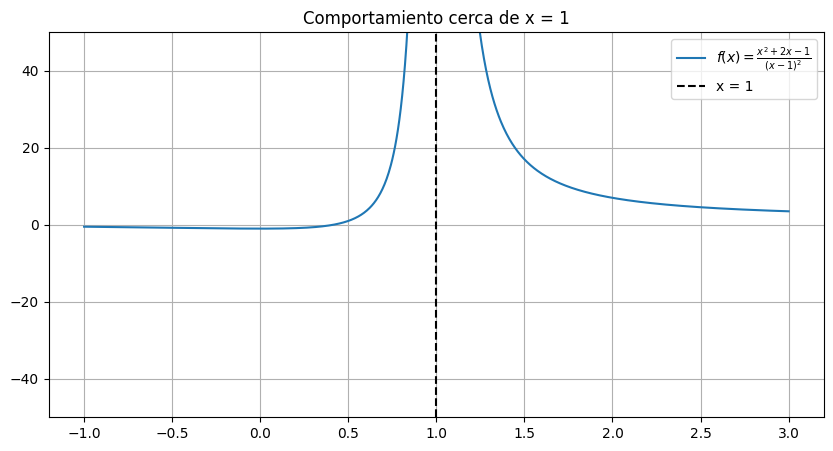

In [4]:

# --- EJECUCIÓN DE LOS EJERCICIOS DE LA SEGUNDA IMAGEN ---
x = sp.Symbol('x')

# (a) Límite cuando x tiende a 1
print("EJERCICIO (a)")
f_a = (x**2 + 2*x - 1) / (x - 1)**2
analizar_limite_punto(f_a, 1)



EJERCICIO (b)
--- Análisis para x -> -2 (por -) ---
Valor del límite (SymPy): -oo

Aproximación Tabular:
      x        f(x)
-2.1000    -54.1000
-2.0100   -504.0100
-2.0010  -5004.0010
-2.0001 -50004.0001
----------------------------------------


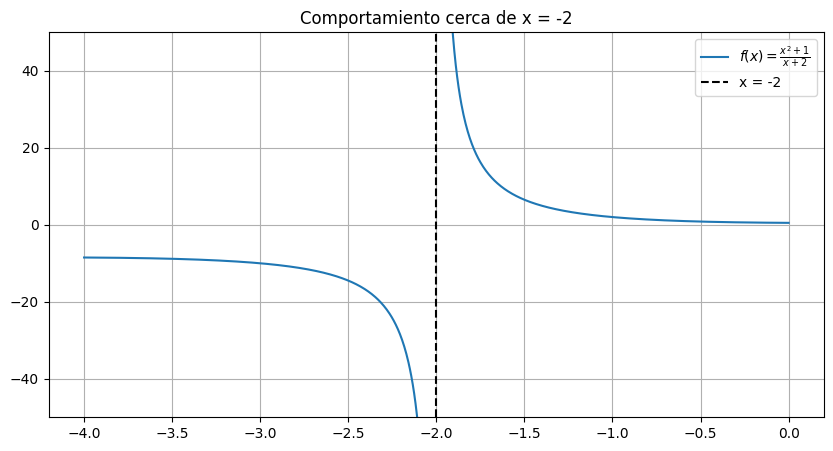

In [5]:

# (b) Límite cuando x tiende a -2 por la izquierda
print("\nEJERCICIO (b)")
f_b = (x**2 + 1) / (x + 2)
analizar_limite_punto(f_b, -2, lateral="-")



EJERCICIO (c)
--- Análisis para x -> 2  ---
Valor del límite (SymPy): zoo

Aproximación Tabular:
     x          f(x)
1.9999  39991.001000
1.9990   3991.009990
1.9900    391.099010
1.9000     31.909091
2.1000    -50.111111
2.0100   -409.101010
2.0010  -4009.010010
2.0001 -40009.001000
----------------------------------------


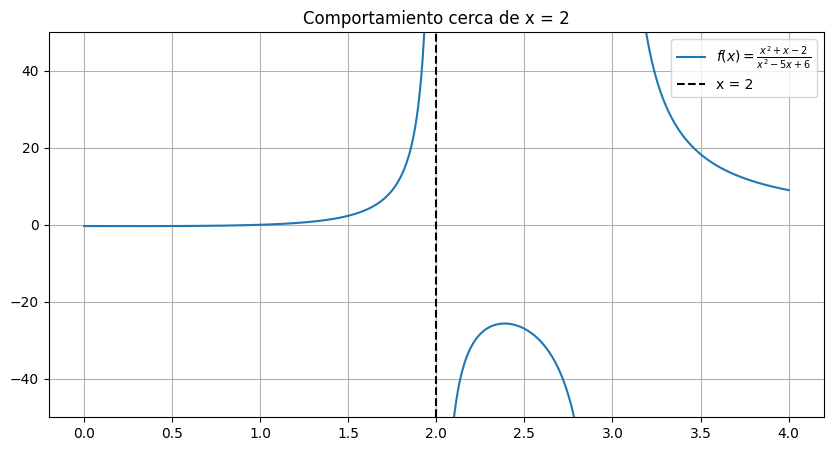

In [6]:

# (c) Límite cuando x tiende a 2
print("\nEJERCICIO (c)")
f_c = (x**2 + x - 2) / (x**2 - 5*x + 6)
analizar_limite_punto(f_c, 2)



# Análisis de los resultados de la imagen:

1. **Ejercicio (a):** El denominador $(x-1)^2$ siempre es positivo. El numerador en $x=1$ es $1+2-1=2$. Como tenemos un número positivo dividido por algo que tiende a $0$ por el lado positivo, el límite es **$+\infty$**.
2. **Ejercicio (b):** Es un límite lateral por la izquierda ($x \to -2^-$). El numerador es $4+1=5$. El denominador $x+2$, al venir por la izquierda (ej. $-2.1$), da un valor negativo pequeño. Positivo entre negativo pequeño resulta en **$-\infty$**.
3. **Ejercicio (c):** Al evaluar directamente obtenemos $0/0$ en $x=2$. Si factorizamos:

$$\frac{(x+2)(x-1)}{(x-2)(x-3)}$$



Como el factor $(x-2)$ queda en el denominador y no se cancela, hay una asíntota vertical. Por la izquierda de 2 el límite tenderá a $+\infty$ y por la derecha a $-\infty$ (o viceversa), por lo que el límite bilateral **no existe** (tiende a infinito con signo distinto).